In [ ]:
!pip install boto3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/14.9 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.3 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
access_key=userdata.get('AWS_ACCESS_KEY_ID')
secret_key=userdata.get('AWS_SECRET_ACCESS_KEY')

In [ ]:
import cv2
import os

video_path = "/content/Kenan.mp4"
output_dir = "frames"
os.makedirs(output_dir, exist_ok=True)

vidcap = cv2.VideoCapture(video_path)
success, image = vidcap.read()
count = 0

while success:
    frame_path = os.path.join(output_dir, f"frame_{count}.jpg")
    cv2.imwrite(frame_path, image)
    success, image = vidcap.read()
    count += 1

print(f"Total frames saved: {count}")

Total frames saved: 1263


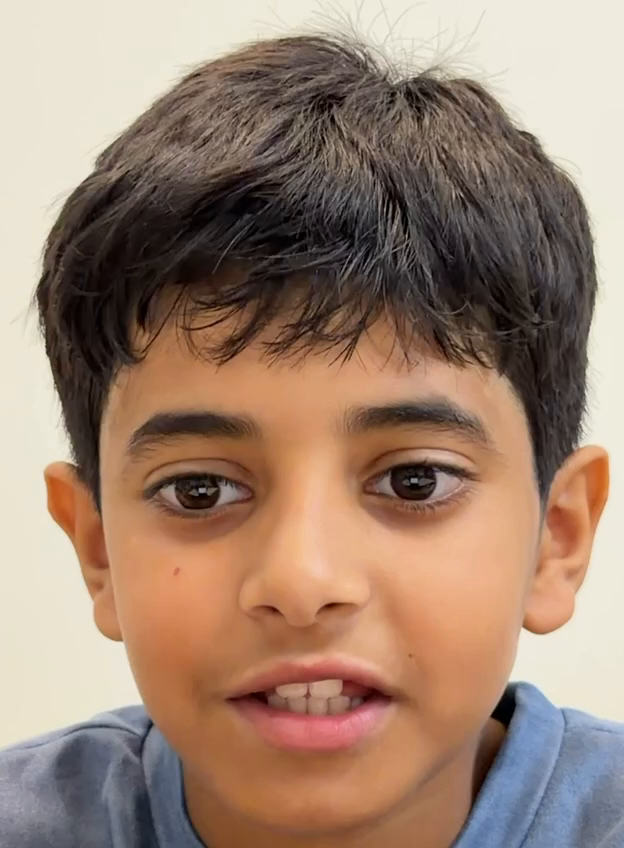

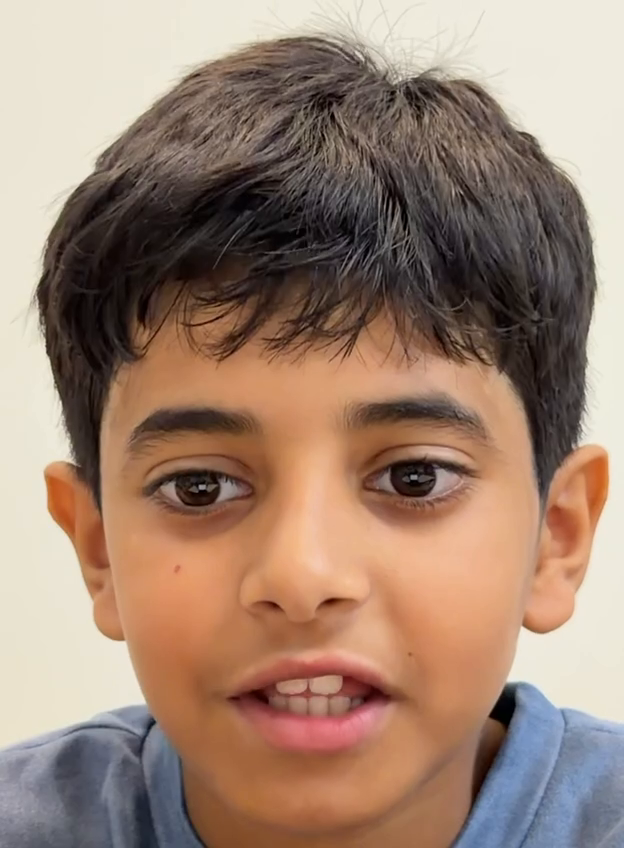

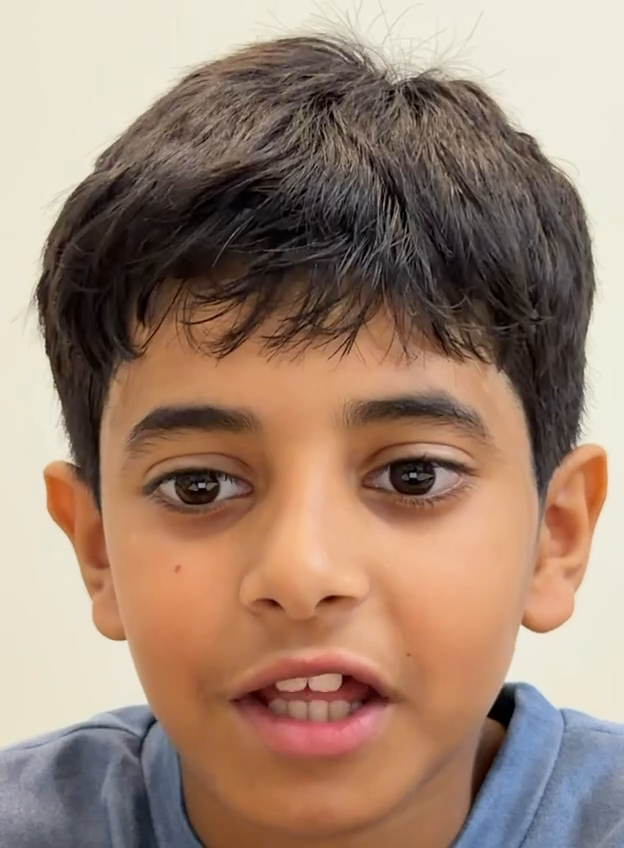

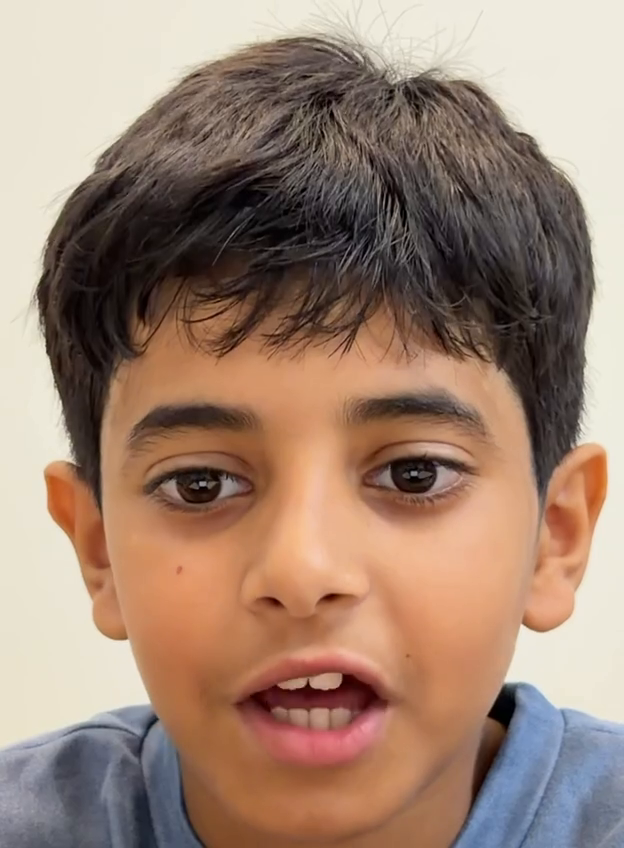

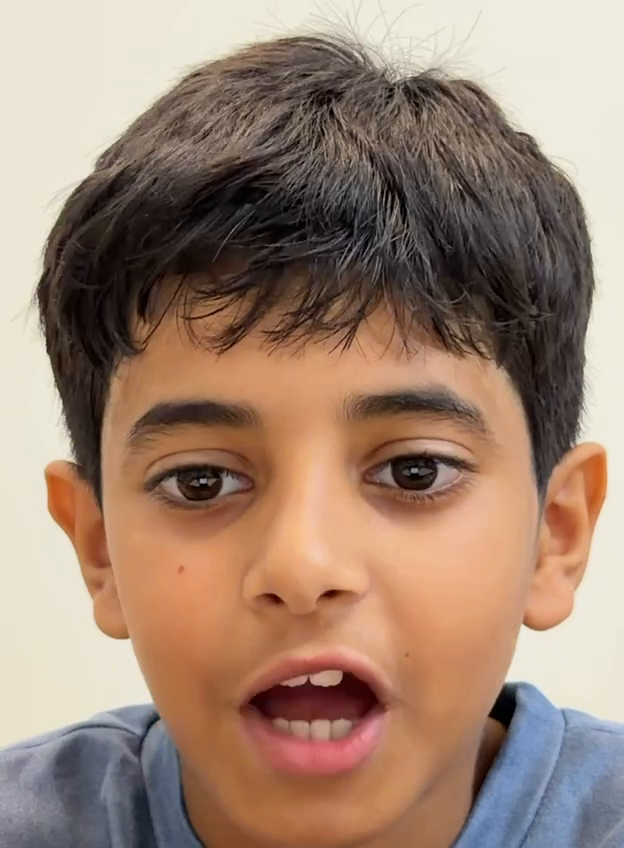

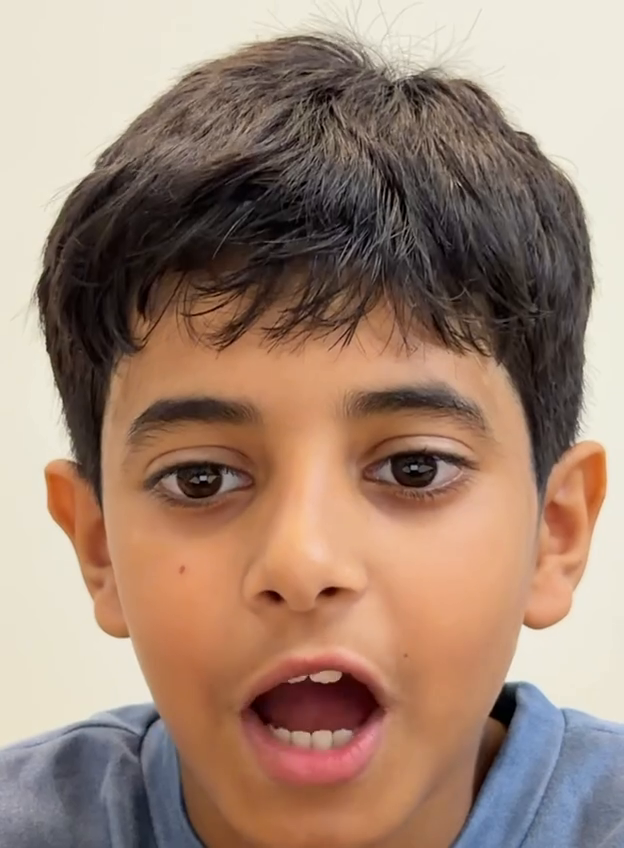

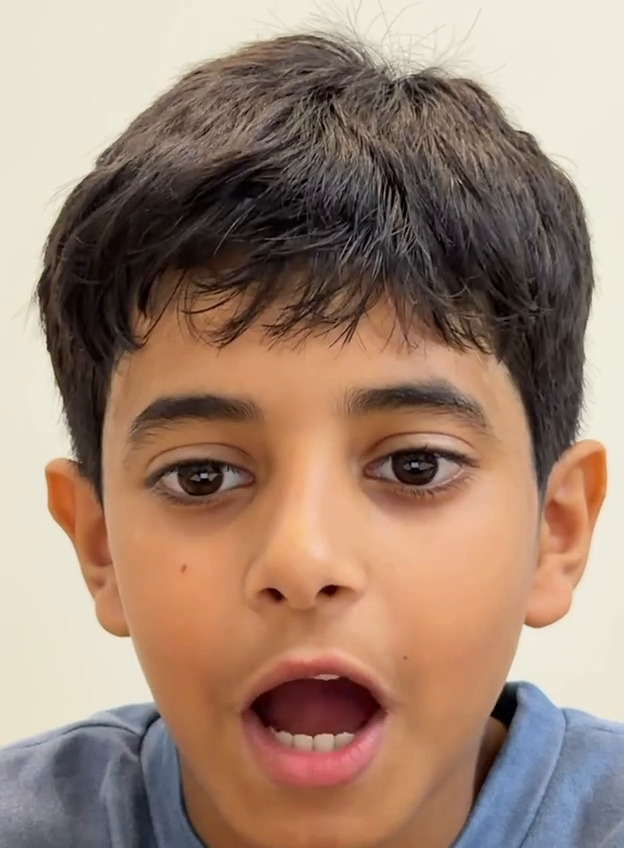

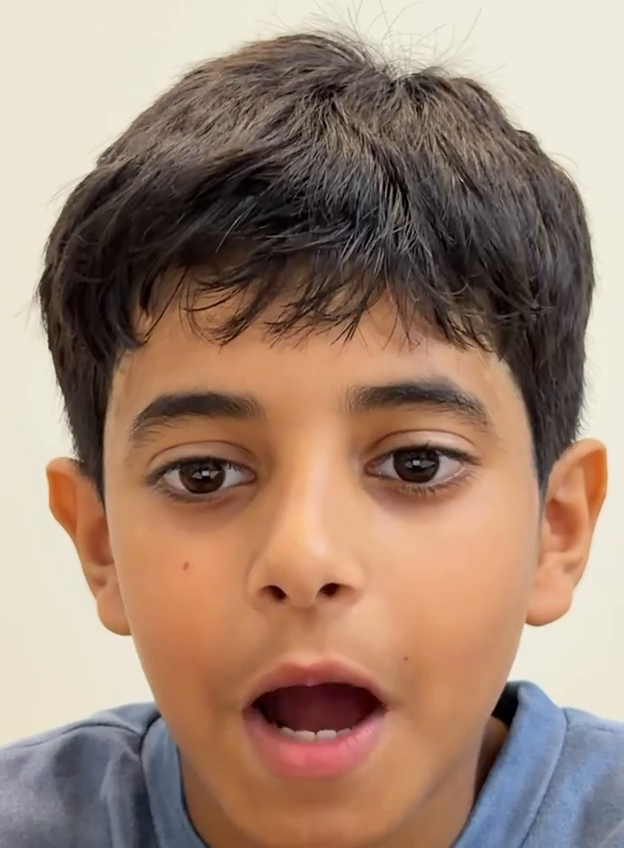

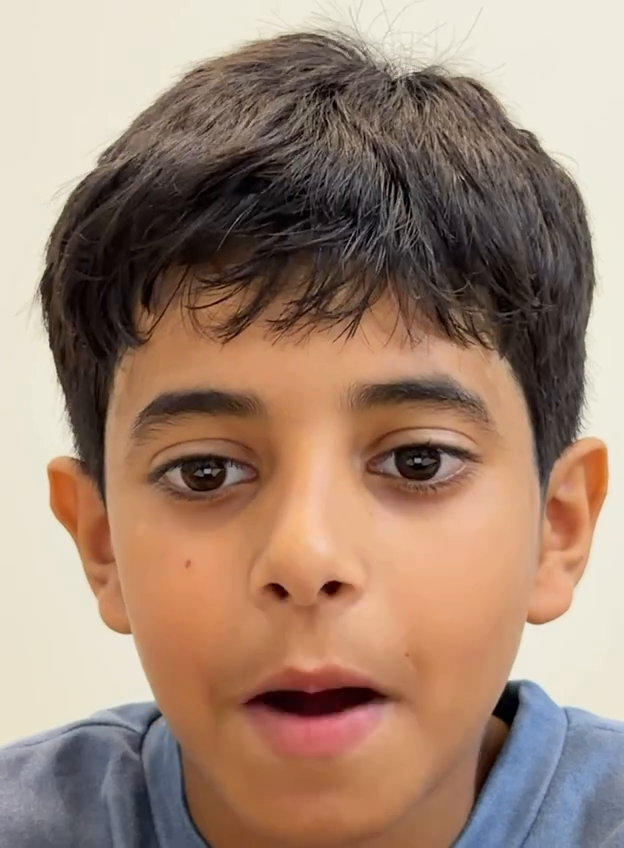

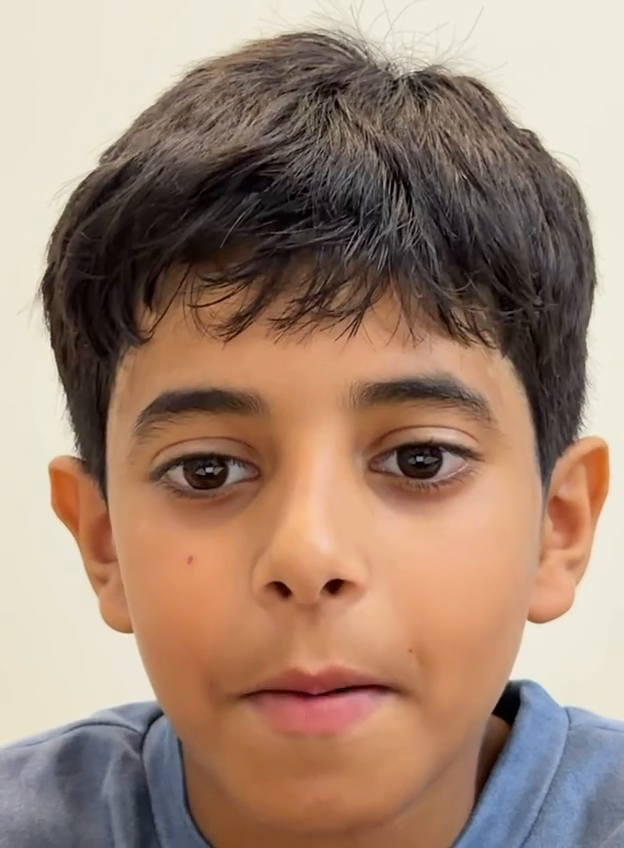

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

video_path = "/content/Kenan.mp4"
vidcap = cv2.VideoCapture(video_path)

num_frames = 10
count = 0

while count < num_frames:
    success, frame = vidcap.read()
    if not success:
        break

    cv2_imshow(frame)
    count += 1

vidcap.release()

In [ ]:
import shutil

shutil.make_archive("frames_zip", 'zip', "frames")

'/content/frames_zip.zip'

In [ ]:
from google.colab import files

files.download("frames_zip.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import boto3
import json
import os


from google.colab import userdata
access_key=userdata.get('AWS_ACCESS_KEY_ID')
secret_key=userdata.get('AWS_SECRET_ACCESS_KEY')
region = "us-east-1"

client = boto3.client(
    'rekognition',
    aws_access_key_id=access_key,
    aws_secret_access_key=secret_key,
    region_name=region
)

frames_dir = "frames"
results = {}

for filename in sorted(os.listdir(frames_dir)):
    if filename.endswith(".jpg"):
        frame_path = os.path.join(frames_dir, filename)
        with open(frame_path, 'rb') as image_file:
            image_bytes = image_file.read()

        try:
            response = client.detect_faces(
                Image={'Bytes': image_bytes},
                Attributes=['ALL']  # 'ALL' gives emotions, age range, etc.
            )
            results[filename] = response  # خزني JSON لكل فريم
        except Exception as e:
            print(f"Error processing {filename}: {e}")


with open("video_faces_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("All frames processed. Results saved in video_faces_results.json")

All frames processed. Results saved in video_faces_results.json


In [ ]:
import json
import pandas as pd

# تحميل الملف
with open("video_faces_results.json", "r") as f:
    data = json.load(f)

rows = []

# أول 10 فريمات فقط
for i, (frame, details) in enumerate(data.items()):
    if i >= 10:
        break

    faces = details.get("FaceDetails", [])

    if not faces:
        continue

    face = faces[0]  # أول وجه (بدون تعديل البيانات)

    row = {"frame": frame}

    # نحط كل المفاتيح زي ما هي
    for key, value in face.items():
        row[key] = value

    rows.append(row)

# DataFrame
df = pd.DataFrame(rows)

df

,frame,BoundingBox,AgeRange,Smile,Eyeglasses,Sunglasses,Gender,Beard,Mustache,EyesOpen,MouthOpen,Emotions,Landmarks,Pose,Quality,Confidence,FaceOccluded,EyeDirection
0,frame_0.jpg,"{'Width': 0.6898031830787659, 'Height': 0.6778...","{'Low': 6, 'High': 12}","{'Value': False, 'Confidence': 92.76777648925781}","{'Value': False, 'Confidence': 98.13560485839844}","{'Value': False, 'Confidence': 99.67821502685547}","{'Value': 'Male', 'Confidence': 97.14544677734...","{'Value': False, 'Confidence': 85.4078369140625}","{'Value': False, 'Confidence': 99.6197738647461}","{'Value': True, 'Confidence': 98.54203796386719}","{'Value': True, 'Confidence': 92.48916625976562}","[{'Type': 'CALM', 'Confidence': 77.8515625}, {...","[{'Type': 'eyeLeft', 'X': 0.3334912657737732, ...","{'Roll': -2.168024778366089, 'Yaw': -3.6874837...","{'Brightness': 84.31236267089844, 'Sharpness':...",99.999870,"{'Value': False, 'Confidence': 99.92057800292969}","{'Yaw': -7.700710773468018, 'Pitch': -3.677691..."
1,frame_1.jpg,"{'Width': 0.6867849826812744, 'Height': 0.6795...","{'Low': 6, 'High': 12}","{'Value': False, 'Confidence': 93.0496826171875}","{'Value': False, 'Confidence': 98.04322814941406}","{'Value': False, 'Confidence': 99.71536254882812}","{'Value': 'Male', 'Confidence': 97.37931823730...","{'Value': False, 'Confidence': 84.97862243652344}","{'Value': False, 'Confidence': 99.59927368164062}","{'Value': True, 'Confidence': 97.52703094482422}","{'Value': True, 'Confidence': 95.61102294921875}","[{'Type': 'CALM', 'Confidence': 52.92578506469...","[{'Type': 'eyeLeft', 'X': 0.3342394232749939, ...","{'Roll': -2.0459697246551514, 'Yaw': -3.627436...","{'Brightness': 84.54149627685547, 'Sharpness':...",99.999878,"{'Value': False, 'Confidence': 99.88412475585938}","{'Yaw': -7.54870080947876, 'Pitch': -4.1783685..."
2,frame_10.jpg,"{'Width': 0.6943120956420898, 'Height': 0.7045...","{'Low': 8, 'High': 12}","{'Value': False, 'Confidence': 99.8552017211914}","{'Value': False, 'Confidence': 95.42202758789062}","{'Value': False, 'Confidence': 97.3342514038086}","{'Value': 'Male', 'Confidence': 99.2724380493164}","{'Value': False, 'Confidence': 85.01922607421875}","{'Value': False, 'Confidence': 99.68211364746094}","{'Value': True, 'Confidence': 79.18975067138672}","{'Value': False, 'Confidence': 99.86868286132812}","[{'Type': 'CALM', 'Confidence': 98.74442291259...","[{'Type': 'eyeLeft', 'X': 0.3463870882987976, ...","{'Roll': -2.9779787063598633, 'Yaw': -2.648656...","{'Brightness': 85.1043930053711, 'Sharpness': ...",99.999931,"{'Value': False, 'Confidence': 99.8688735961914}","{'Yaw': -5.893174171447754, 'Pitch': -8.585550..."
3,frame_100.jpg,"{'Width': 0.6837191581726074, 'Height': 0.7126...","{'Low': 8, 'High': 12}","{'Value': False, 'Confidence': 99.34614562988281}","{'Value': False, 'Confidence': 98.8427734375}","{'Value': False, 'Confidence': 99.54595184326172}","{'Value': 'Male', 'Confidence': 99.21053314208...","{'Value': False, 'Confidence': 83.40762329101562}","{'Value': False, 'Confidence': 99.683349609375}","{'Value': True, 'Confidence': 83.2900619506836}","{'Value': True, 'Confidence': 94.35728454589844}","[{'Type': 'SURPRISED', 'Confidence': 99.297561...","[{'Type': 'eyeLeft', 'X': 0.3708518147468567, ...","{'Roll': -5.088167190551758, 'Yaw': -0.1921696...","{'Brightness': 84.92802429199219, 'Sharpness':...",99.999954,"{'Value': False, 'Confidence': 99.81249237060547}","{'Yaw': -1.019516944885254, 'Pitch': -8.457900..."
4,frame_1000.jpg,"{'Width': 0.7019631862640381, 'Height': 0.6742...","{'Low': 8, 'High': 12}","{'Value': False, 'Confidence': 99.9637680053711}","{'Value': False, 'Confidence': 99.74463653564453}","{'Value': False, 'Confidence': 99.7625732421875}","{'Value': 'Male', 'Confidence': 99.73832702636...","{'Value': False, 'Confidence': 75.62898254394531}","{'Value': False, 'Confidence': 99.53363800048828}","{'Value': True, 'Confidence': 58.724586486816406}","{'Value': False, 'Confidence': 99.19210815429688}","[{'Type': 'SAD', 'Confiden

Feature Extraction

In [ ]:
import json
import pandas as pd
import re

# Load JSON file
with open("/content/video_faces_results.json", "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []

for frame_name, frame_data in data.items():

    # Extract numeric frame number
    frame_number = int(re.search(r'\d+', frame_name).group())

    for face in frame_data.get("FaceDetails", []):

        # Get strongest emotion
        emotions = face.get("Emotions", [])
        if emotions:
            top_emotion = max(emotions, key=lambda x: x["Confidence"])
            emotion_type = top_emotion["Type"]
            emotion_conf = top_emotion["Confidence"]
        else:
            emotion_type = None
            emotion_conf = None

        rows.append({
            "Frame": frame_number,

            "Emotion": emotion_type,
            "Emotion_Confidence": emotion_conf,

            "Pose_Roll": face["Pose"]["Roll"],
            "Pose_Yaw": face["Pose"]["Yaw"],
            "Pose_Pitch": face["Pose"]["Pitch"],

            "Eye_Yaw": face["EyeDirection"]["Yaw"],
            "Eye_Pitch": face["EyeDirection"]["Pitch"]
        })


In [ ]:
# DataFrame For Some features
dataset = pd.DataFrame(rows)

dataset = dataset.sort_values("Frame")
dataset.to_csv("face_dataset.csv", index=False)

print("CSV file saved successfully")

CSV file saved successfully


In [ ]:
import pandas as pd

data = pd.read_csv('/content/face_dataset.csv')
data

,Frame,Emotion,Emotion_Confidence,Pose_Roll,Pose_Yaw,Pose_Pitch,Eye_Yaw,Eye_Pitch
0,0,CALM,77.851562,-2.168025,-3.687484,2.474533,-7.700711,-3.677691
1,1,CALM,52.925785,-2.045970,-3.627436,2.533959,-7.548701,-4.178369
2,2,SURPRISED,74.033516,-2.659070,-3.546500,2.660915,-7.748859,-3.892025
3,3,SURPRISED,94.534676,-3.028142,-3.503761,2.956968,-5.856568,-4.751001
4,4,SURPRISED,98.972038,-2.828164,-3.407089,3.179238,-6.234347,-5.249926
...,...,...,...,...,...,...,...,...
1258,1258,CALM,50.337894,-6.493395,-4.040390,-0.491221,-8.519117,-12.237779
1259,1259,SURPRISED,60.258205,-6.264841,-3.913370,0.175965,-8.465284,-12.177328
1260,1260,CALM,45.836124,-6.279347,-3.731991,1.114866,-8.201665,-12.606197
1261,1261,CALM,49.277344,-6.183837,-3.939589,2.088567,-8.624795,-12.941848
